In [ ]:
class Value:
    def __init__(self, data,_children=(),_op='',label=''):
        self.data = data
        self._prev = _children
        self.label = label
        self._op = _op
        self.grad = 0.0
        self.backward = lambda:None

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data,(self,other),'+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out.backward = _backward
            
        return out
    
    def __radd__(self, other):
        return self + other
    
    def __mul__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data,(self,other),'*')

        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad

        out.backward = _backward

        return out
    
    def __rmul__(self, other):
        return self * other
    
    def __sub__(self, other):
        return self + (-other)
    
    def __neg__(self):
        return self * -1
    
    def __truediv__(self, other):
        return self * other**-1
    
    def backward(self):
        self.grad = 1.0
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        # print(topo)
        for n in reversed(topo):
            n._backward()


In [13]:
a = Value(2,label='a')
b = Value(3,label='b')

c= a+b;c.label = 'c'
c

Value(data=5)

In [14]:
def trace(root):
    nodes,edges = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges


from graphviz import Digraph

def draw_dot(root):
    nodes,edgees = trace(root)
    dot = Digraph(format='svg',graph_attr={'rankdir':'LR'})
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid,label="{ %s | data %.4f | grad %.4f }" % (n.label,n.data,n.grad),shape='record')
        if n._op:
            dot.node(name=uid + n._op,label=n._op)
            dot.edge(uid + n._op,uid)

    for n1,n2 in edgees:
        dot.edge(str(id(n1)),str(id(n2)) + n2._op)
    return dot

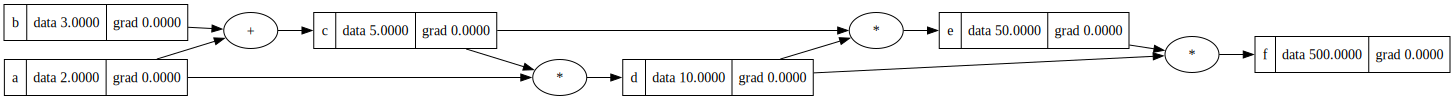

In [16]:
d = c * a ; d.label = "d"
e = d*c; e.label = "e"
f = d*e; f.label = "f"
draw_dot(f)

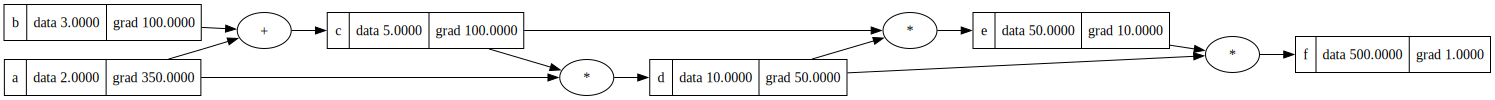

In [20]:
f.grad = 1.0
f.backward()
e.backward()
d.backward()
c.backward()
draw_dot(f)


In [26]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(f)
print(topo)

[Value(data=2), Value(data=3), Value(data=5), Value(data=10), Value(data=50), Value(data=500)]
